Notebook for building analysis of resulting synapse distribution

In [1]:
import os
import sys
sys.path.append("../")
sys.path.append("../Modules/")
import pandas as pd
import h5py

from Modules import analysis
from Modules import view_synapses

## Pick Simulation

In [2]:
sim_dir = "/home/drfrbc/Neural-Modeling/scripts/2025-04-01-00-13-Running_5sec_STA_noRhyth/sta_Complex_DepthPeriInh0.0000_DepthDistalInh0.0000_InhTuftDensity0.3300_0.4400_0.3850_0.0572_0.2200_0.1100_ExcTuftDensity0.4860_0.3240_0.1080_0.5400_1.2982_Np5000"

sim_dir = "/home/drfrbc/Neural-Modeling/scripts/2025-04-02-11-37-Running_5sec_STA_noRhyth/sta_Complex_DepthPeriInh0.0150_DepthDistalInh0.0150_InhTuftDensity0.3300_0.4400_0.3850_0.0572_0.2200_0.1650_ExcTuftDensity0.4860_0.3240_0.1080_0.5400_0.6491_Np5000"

sim_dir = "/home/drfrbc/Neural-Modeling/scripts/2025-04-02-18-27-Running_5sec_STA_noRhyth/sta_Complex_DepthPeriInh0.0150_DepthDistalInh0.0150_InhTuftDensity0.3300_0.4400_0.3850_0.0572_0.2200_0.1650_ExcTuftDensity0.4860_0.3240_0.1080_0.5400_0.6491_Np5000"

sim_dir = "/home/drfrbc/Neural-Modeling/scripts/2025-04-02-18-13-Running_5sec_STA_noRhyth/sta_Complex_DepthPeriInh0.0150_DepthDistalInh0.0150_InhTuftDensity0.3300_0.4400_0.3850_0.0572_0.2200_0.1650_ExcTuftDensity0.4860_0.3240_0.1080_0.5400_0.6491_Np5000"

sim_dir = "/home/drfrbc/Neural-Modeling/scripts/2025-04-04-13-49-L23_5sec_STA_Rhyth/sta_Complex_DepthPeriInh0.0150_DepthDistalInh0.0150_InhTuftDensity0.2200_0.2200_0.1650_ExcTuftDensity2.1600_2.1600_Np5000"

sim_dir = "/home/drfrbc/Neural-Modeling/scripts/2025-04-04-14-11-L23_5sec_STA_Rhyth/sta_Complex_DepthPeriInh0.0150_DepthDistalInh0.0150_InhDens0.0220_0.0220_0.0165_ExcDens4.3200_4.3200_Np5000"

In [3]:
save_folder = os.path.join(sim_dir, 'synapse_distribution')

if not os.path.exists(save_folder):
    os.mkdir(save_folder)

## Loading Data

Read files

In [4]:
# read synapses from simulation
syn_data = view_synapses.read_synapse_distribution_file(sim_dir)

# read segment data from simulation
seg_data = pd.read_csv(os.path.join(sim_dir, "segment_data.csv"))

# read transfer impedances
imp_df = view_synapses.read_transfer_impedance_file(sim_dir, loc='soma')
seg_data['soma_trans_imp'] = imp_df.beta_active

# add segment information of synapse location
syn_data = view_synapses.add_seg_info_to_syn_data(syn_data, seg_data)

Choose transfer impedance for analysis

In [5]:
# choose transfer impedance
seg_data['soma_trans_imp'] = imp_df.beta_active

Check that the seg indices correspond

In [6]:
# checks
if len(seg_data) != len(imp_df):
    IndexError(f"{len(seg_data)} != {max(syn_data.seg_id)}. The imp_df does not correspond to seg_data")
if len(seg_data) != max(syn_data.seg_id):
    print(f"{len(seg_data)} != {max(syn_data.seg_id)} need to check that syn_data.seg_id actually corresponds to seg_data row index.")

464 != 112 need to check that syn_data.seg_id actually corresponds to seg_data row index.


Previews

In [7]:
seg_data

,Unnamed: 0,section,idx_in_section_type,seg_half_seg_RA,L,seg,pseg,Section_L,Section_diam,Distance,...,pc_1,pc_2,p1_0,p1_1,p1_2,r,dl_0,dl_1,dl_2,soma_trans_imp
0,0,soma,0,0.066139,9.740997,soma[0](0.5),None,9.740997,9.741000,0.000000,...,394.679993,38.639999,482.032898,394.679993,38.639999,4.870500,9.740997,0.000000,0.000000,1.000000
1,1,dend,0,28.040132,4.910149,dend[0](0.0166667),soma[0](0.5),147.304478,0.395671,2.455075,...,394.691748,39.170321,486.322373,395.256710,39.660557,0.192748,4.741867,0.906215,0.759556,0.942671
2,2,dend,0,35.355691,4.910149,dend[0](0.05),dend[0](0.0166667),147.304478,0.395671,7.365224,...,395.874547,40.857406,489.655899,397.177887,42.365938,0.171652,3.333527,1.921177,2.705381,0.767165
3,3,dend,0,22.760053,4.910149,dend[0](0.0833333),dend[0](0.05),147.304478,0.395671,12.275373,...,398.376591,43.296312,493.506436,399.804012,43.720345,0.213940,3.850536,2.626124,1.354407,0.660994
4,4,dend,0,29.146727,4.910149,dend[0](0.116667),dend[0](0.0833333),147.304478,0.395671,17.185522,...,401.553603,43.888654,497.293522,402.834571,44.020453,0.189053,3.787087,3.030559,0.300108,0.609810
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
459,459,axon,1,3.942332,4.285714,axon[1](0.357143),axon[1](0.214286),30.000000,1.000000,40.714286,...,432.180339,38.639999,493.851779,434.154041,38.639999,0.500000,1.668936,3.947404,0.000000,0.820393
460,460,axon,1,3.942332,4.285714,axon[1](0.5),axon[1](0.357143),30.000000,1.000000,45.000000,...,436.127743,38.639999,495.520715,438.101445,38.639999,0.500000,1.668936,3.947404,0.000000,0.804196
461,461,axon,1,3.942332,4.285714,axon[1](0.642857),axon[1](0.5),30.000000,1.000000,49.285714,...,440.075149,38.639999,497.189652,442.048851,38.639999,0.500000,1.668936,3.947404,0.000000,0.788463
462,462,axon,1,3.942332,4.285714,axon[1](0.785714),axon[1](0.642857),30.000000,1.000000,53.571429,...,444.022555,38.639999,498.858589,445.996257,38.639999,0.500000,1.668936,3.947404,0.000000,0.773179


In [8]:
syn_data

,mean_firing_rate,pc_name,seg_id,synapse_type,weight,Distance,section,soma_trans_imp,seg_L
0,19.2,b'fg_0_cell35',58,inh_perisomatic,4.522388,57.332216,dend,0.331378,4.905787
1,21.0,b'fg_0_cell29',59,inh_perisomatic,4.730853,62.238002,dend,0.298813,4.905787
2,13.6,b'fg_0_cell42',32,inh_perisomatic,4.770071,6.610533,dend,0.723270,4.407022
3,18.9,b'fg_0_cell11',59,inh_perisomatic,4.502409,62.238002,dend,0.298813,4.905787
4,20.3,b'fg_0_cell23',30,inh_perisomatic,4.540078,144.849403,dend,0.132429,4.910149
...,...,...,...,...,...,...,...,...,...
9388,7.8,b'fg_47_cell5',10,exc_dend,1.246347,46.646418,dend,0.347796,4.910149
9389,7.1,b'fg_9_cell58',56,exc_dend,1.024581,47.520642,dend,0.371895,4.905787
9390,8.5,b'fg_23_cell52',35,exc_dend,1.146875,19.831599,dend,0.555190,4.407022
9391,6.7,b'fg_38_cell15',39,exc_dend,1.084831,37.609038,dend,0.438779,4.705725


## Plotting on Morphology

In [9]:
import pandas as pd

# Assume df is your existing dataframe
# Example: Create a column that classifies synapses as 'exc' or 'inh'
syn_data['synapse_class'] = syn_data['synapse_type'].apply(lambda x: 'exc' if x.startswith('exc') else ('inh' if x.startswith('inh') else None))

# Filter the dataframe into excitatory and inhibitory synapses
df_exc = syn_data[syn_data['synapse_class'] == 'exc']
df_inh = syn_data[syn_data['synapse_class'] == 'inh']

# Group by 'seg_id' and aggregate all other columns into lists
df_exc_grouped = df_exc.groupby('seg_id').agg(lambda x: list(x)).reset_index()
df_inh_grouped = df_inh.groupby('seg_id').agg(lambda x: list(x)).reset_index()

# Display the resulting dataframes
print("Excitatory synapses grouped by segment:")
print(df_exc_grouped)
print("\nInhibitory synapses grouped by segment:")
print(df_inh_grouped)


Excitatory synapses grouped by segment:
     seg_id                                   mean_firing_rate  \
0         1  [7.1000000000000005, 7.1000000000000005, 6.7, ...   
1         2  [7.5, 4.5, 4.5, 7.7, 6.0, 6.0, 7.0, 4.89999999...   
2         3  [6.2, 4.0, 7.7, 7.0, 7.6, 7.1000000000000005, ...   
3         4  [9.299999999999999, 5.2, 7.8, 6.3, 7.7, 6.1000...   
4         5  [6.3, 5.8, 6.1000000000000005, 6.4, 6.0, 6.0, ...   
..      ...                                                ...   
107     108  [6.8999999999999995, 6.1000000000000005, 4.6, ...   
108     109  [7.9, 5.5, 5.7, 5.7, 5.2, 4.3, 7.3, 7.5, 7.9, ...   
109     110  [6.8999999999999995, 7.4, 7.2, 4.2, 7.2, 7.8, ...   
110     111  [4.8999999999999995, 7.2, 8.1, 6.1000000000000...   
111     112  [7.5, 6.3, 6.5, 7.4, 6.8, 5.8, 7.6, 8.0, 7.4, ...   

                                               pc_name  \
0    [b'fg_16_cell84', b'fg_16_cell84', b'fg_16_cel...   
1    [b'fg_30_cell11', b'fg_30_cell25', b'fg_30_cel

In [10]:
import numpy as np
for df in [df_exc_grouped, df_inh_grouped]:

    df['seg_L'] = df['seg_L'].apply(np.mean)
    df['pc_name'] = np.array(df['pc_name'].apply(np.array))
    df['num_syns'] = df['pc_name'].apply(len)
    df['num_cells'] = df['pc_name'].apply(np.unique).apply(len) # number of cells per segment
    df['weight_mean'] = df['weight'].apply(np.mean) # mean weight
    df['weight_std'] = df['weight'].apply(np.std) # mean weight
    df['weight_sum'] = df['weight'].apply(np.sum) # mean weight

    # do same for fr
    df['fr_mean'] = df['mean_firing_rate'].apply(np.mean) # mean weight
    df['fr_std'] = df['mean_firing_rate'].apply(np.std) # mean weight
    df['fr_sum'] = df['mean_firing_rate'].apply(np.sum) # mean weight

    # Multiply weight and firing rate and sum
    df['weightXfr'] = df.apply(lambda row: [a * b for a, b in zip(row['weight'], row['mean_firing_rate'])], axis=1)
    df['weightXfr_sum'] = df['weightXfr'].apply(np.sum) # mean weight

    df['syn_density'] = df.apply(lambda row: [row['num_syns'] / row['seg_L']], axis=1)

In [11]:
df_inh_grouped

,seg_id,mean_firing_rate,pc_name,synapse_type,weight,Distance,section,soma_trans_imp,seg_L,synapse_class,...,num_cells,weight_mean,weight_std,weight_sum,fr_mean,fr_std,fr_sum,weightXfr,weightXfr_sum,syn_density
0,1,[16.0],[b'fg_0_cell12'],[inh_perisomatic],[4.542039728515582],[2.4550746328731514],[dend],[0.9426706479413364],4.910149,[inh],...,1,4.542040,0.000000,4.542040,16.000000,0.000000,16.0,[72.67263565624931],72.672636,[0.2036597964497945]
1,2,[18.2],[b'fg_0_cell28'],[inh_dend],[1.9349515258486167],[7.365223898619455],[dend],[0.7671646573446694],4.910149,[inh],...,1,1.934952,0.000000,1.934952,18.200000,0.000000,18.2,[35.216117770444825],35.216118,[0.2036597964497945]
2,7,[4.6],[b'fg_5_cell7'],[inh_dend],[1.9386369895715252],[31.91597022735097],[dend],[0.4468348297711413],4.910149,[inh],...,1,1.938637,0.000000,1.938637,4.600000,0.000000,4.6,[8.917730152029016],8.917730,[0.2036597964497945]
3,8,[14.1],[b'fg_0_cell21'],[inh_dend],[1.9225752988240339],[36.82611949309727],[dend],[0.4228663512728792],4.910149,[inh],...,1,1.922575,0.000000,1.922575,14.100000,0.000000,14.1,[27.10831171341888],27.108312,[0.2036597964497945]
4,9,[18.0],[b'fg_5_cell10'],[inh_dend],[2.008665442252078],[41.73626875884358],[dend],[0.3877039040602996],4.910149,[inh],...,1,2.008665,0.000000,2.008665,18.000000,0.000000,18.0,[36.155977960537406],36.155978,[0.2036597964497945]
5,10,[18.5],[b'fg_5_cell5'],[inh_dend],[1.8247371949965887],[46.64641802458988],[dend],[0.3477956451307414],4.910149,[inh],...,1,1.824737,0.000000,1.824737,18.500000,0.000000,18.5,[33.75763810743689],33.757638,[0.2036597964497945]
6,11,[16.8],[b'fg_4_cell27'],[inh_dend],[1.8423957430576932],[51.55656729033618],[dend],[0.3286623302955838],4.910149,[inh],...,1,1.842396,0.000000,1.842396,16.800000,0.000000,16.8,[30.952248483369246],30.952248,[0.2036597964497945]
7,19,[10.7],[b'fg_4_cell38'],[inh_dend],[1.898235824955459],[90.8377614163066],[dend],[0.2235701793915491],4.910149,[inh],...,1,1.898236,0.000000,1.898236,10.700000,0.000000,10.7,[20.31112332702341],20.311123,[0.2036597964497945]
8,21,[22.599999999999998],[b'fg_4_cell49'],[inh_dend],[1.9096946330478455],[100.65805994779922],[dend],[0.1950651711022399],4.910149,[inh],...,1,1.909695,0.000000,1.909695,22.600000,0.000000,22.6,[43.1590987068813],43.159099,[0.2036597964497945]
9,26,"[15.7, 15.7]","[b'fg_2_cell4', b'fg_2_cell4']","[inh_dend, inh_dend]","[1.880803459900102, 1.7701634519709333]","[125.20880627653072, 125.20880627653072]","[dend, dend]","[0.1545719125300222, 0.1545719125300222]",4.910149,"[inh, inh]",...,1,1.825483,0.055320,3.650967,15.700000,0.000000,31.4,"[29.5286143204316, 27.791566195943652]",57.320181,[0.407319592899589]


In [12]:
df_exc_grouped

,seg_id,mean_firing_rate,pc_name,synapse_type,weight,Distance,section,soma_trans_imp,seg_L,synapse_class,...,num_cells,weight_mean,weight_std,weight_sum,fr_mean,fr_std,fr_sum,weightXfr,weightXfr_sum,syn_density
0,1,"[7.1000000000000005, 7.1000000000000005, 6.7, ...","[b'fg_16_cell84', b'fg_16_cell84', b'fg_16_cel...","[exc_dend, exc_dend, exc_dend, exc_dend, exc_d...","[1.0650517223474338, 1.1355192697498162, 1.142...","[2.4550746328731514, 2.4550746328731514, 2.455...","[dend, dend, dend, dend, dend, dend, dend, den...","[0.9426706479413364, 0.9426706479413364, 0.942...",4.910149,"[exc, exc, exc, exc, exc, exc, exc, exc, exc, ...",...,16,1.165631,0.121518,115.397421,7.126263,1.178562,705.5,"[7.561867228666781, 8.062186815223695, 7.65559...",820.441737,[20.16231984852965]
1,2,"[7.5, 4.5, 4.5, 7.7, 6.0, 6.0, 7.0, 4.89999999...","[b'fg_30_cell11', b'fg_30_cell25', b'fg_30_cel...","[exc_dend, exc_dend, exc_dend, exc_dend, exc_d...","[1.2474475133078498, 1.1760348786652615, 1.221...","[7.365223898619455, 7.365223898619455, 7.36522...","[dend, dend, dend, dend, dend, dend, dend, den...","[0.7671646573446694, 0.7671646573446694, 0.767...",4.910149,"[exc, exc, exc, exc, exc, exc, exc, exc, exc, ...",...,18,1.171431,0.113824,115.971710,6.420202,0.897807,635.6,"[9.355856349808873, 5.292156953993676, 5.49689...",745.434069,[20.16231984852965]
2,3,"[6.2, 4.0, 7.7, 7.0, 7.6, 7.1000000000000005, ...","[b'fg_49_cell19', b'fg_49_cell56', b'fg_49_cel...","[exc_dend, exc_dend, exc_dend, exc_dend, exc_d...","[1.4178396166458644, 0.9871608364962398, 1.039...","[12.275373164365757, 12.275373164365757, 12.27...","[dend, dend, dend, dend, dend, dend, dend, den...","[0.6609944984334246, 0.6609944984334246, 0.660...",4.910149,"[exc, exc, exc, exc, exc, exc, exc, exc, exc, ...",...,38,1.172150,0.109842,99.632722,6.712941,1.222321,570.6,"[8.79060562320436, 3.948643345984959, 8.002479...",669.229119,[17.31108269823253]
3,4,"[9.299999999999999, 5.2, 7.8, 6.3, 7.7, 6.1000...","[b'fg_40_cell70', b'fg_40_cell62', b'fg_40_cel...","[exc_dend, exc_dend, exc_dend, exc_dend, exc_d...","[1.1670530430929629, 1.211655599861385, 1.4987...","[17.185522430112062, 17.185522430112062, 17.18...","[dend, dend, dend, dend, dend, dend, dend, den...","[0.6098095959065509, 0.6098095959065509, 0.609...",4.910149,"[exc, exc, exc, exc, exc, exc, exc, exc, exc, ...",...,62,1.175164,0.124716,109.290216,6.970968,1.343769,648.3,"[10.853593300764553, 6.300609119279202, 11.690...",763.724538,[18.94036106983088]
4,5,"[6.3, 5.8, 6.1000000000000005, 6.4, 6.0, 6.0, ...","[b'fg_17_cell89', b'fg_17_cell73', b'fg_17_cel...","[exc_dend, exc_dend, exc_dend, exc_dend, exc_d...","[1.2309005056689042, 1.2955255210200236, 1.119...","[22.095671695858364, 22.095671695858364, 22.09...","[dend, dend, dend, dend, dend, dend, dend, den...","[0.5300950813102117, 0.5300950813102117, 0.530...",4.910149,"[exc, exc, exc, exc, exc, exc, exc, exc, exc, ...",...,40,1.176548,0.128296,112.948640,6.716667,1.017520,644.8,"[7.754673185714096, 7.514048021916136, 6.83023...",757.653948,[19.55134045918027]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,108,"[6.8999999999999995, 6.1000000000000005, 4.6, ...","[b'fg_22_cell66', b'fg_22_cell49', b'fg_22_cel...","[exc_apic, exc_apic, exc_apic, exc_apic, exc_a...","[1.2017383966917061, 1.211244795761306, 1.0324...","[33.90048126101259, 33.90048126101259, 33.9004...","[dend, dend, dend, dend, dend, dend, dend, den...","[0.3937744256659131, 0.3937744256659131, 0.393...",4.992668,"[exc, exc, exc, exc, exc, exc, exc, exc, exc, ...",...,13,1.196528,0.117903,87.346510,6.323288,0.969468,461.6,"[8.291994937172772, 7.3885932541439665, 4.7494...",551.613359,[14.621440620271347]
108,109,"[7.9, 5.5, 5.7, 5.7, 5.2, 4.3, 7.3, 7.5, 7.9, ...","[b'fg_2_cell83', b'fg_2_cell57', b'fg_2_cell94...","[exc_apic, exc_apic, exc_apic, exc_apic, exc_a...","[1.3711783821445394, 1.3494597991799728, 1.205...","[38.89314935001005, 38.89314935001005, 38.8931...

In [ ]:
import matplotlib.pyplot as plt
def plot_var_on_morph_for_both_syn_types(df_inh:pd.DataFrame,
                                         df_exc:pd.DataFrame,
                                         var:str,
                                         cbar_label:str,
                                         title_suffix:str,
                                         save_folder:str,
                                         clim_max):
    # clim_maxes = [4, 20]
    radius_scale=5
    fig, axes = plt.subplots(1, 2, figsize=(24, 12), subplot_kw={'projection': '3d'})
    for i,syn_type, syn_df in zip([0,1],['inh', 'exc'], [df_inh, df_exc]):

        # ours_syn_data_by_this_syntype = syn_data[syn_data['synapse_type'].str.contains(syn_type, na=False)]

        # synapse_counts_ours = view_synapses.build_synapse_counts_dict(ours_syn_data_by_this_syntype, seg_id_column='seg_id')
        # synapse_counts_bens.pop(0) # remove soma segment since it has way more synapses 
        # synapse_counts_ours.pop(0) # remove soma segment since it has way more synapses 
        title = f"{syn_type} {title_suffix}"
        var_dict = syn_df.set_index('seg_id')[var].to_dict()

        # for ax, title, synapse_counts in zip(axes, titles, synapse_counts_dicts):
        view_synapses.plot_morphology(seg_data,  #seg_data[seg_data['section']=='dend'], 
                                    seg_id_column='seg_id', 
                                        variable_dict=var_dict, 
                                        ax=axes[i], 
                                    #   elevation=elevation,
                                    #   azimuth=azimuth,
                                        radius_scale= radius_scale,
                                        title= title,
                                        clim_max= clim_max,
                                        cbar_label = cbar_label
                                        )
        
    plt.tight_layout()
    fig.savefig(os.path.join(save_folder, f'{var}.png'),dpi=300)

Total Input

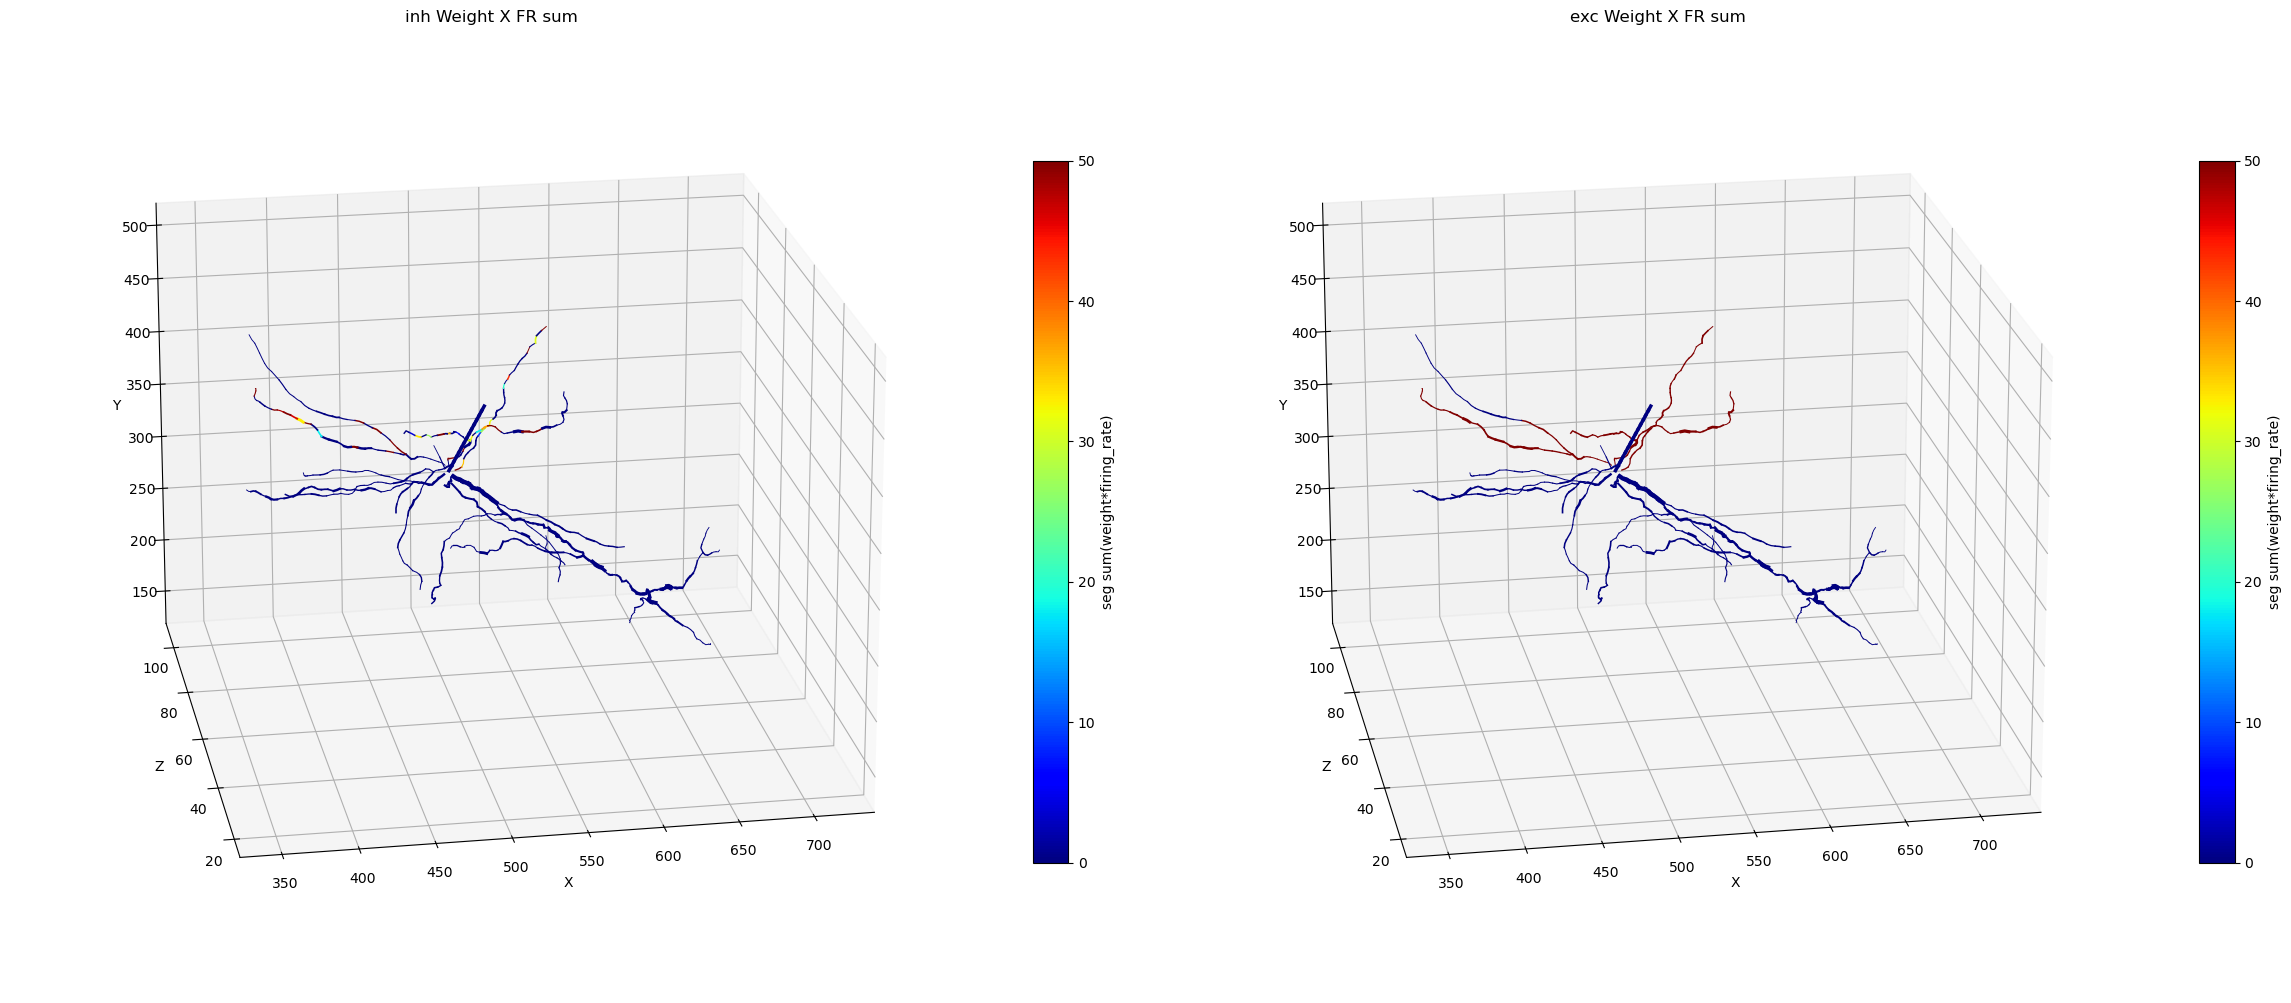

In [14]:
plot_var_on_morph_for_both_syn_types(df_inh=df_inh_grouped,
                                         df_exc=df_exc_grouped,
                                         var='weightXfr_sum',
                                         cbar_label='seg sum(weight*firing_rate)',
                                         title_suffix='Weight X FR sum',
                                         save_folder=save_folder,
                                         clim_max = 50)

Firing Rate

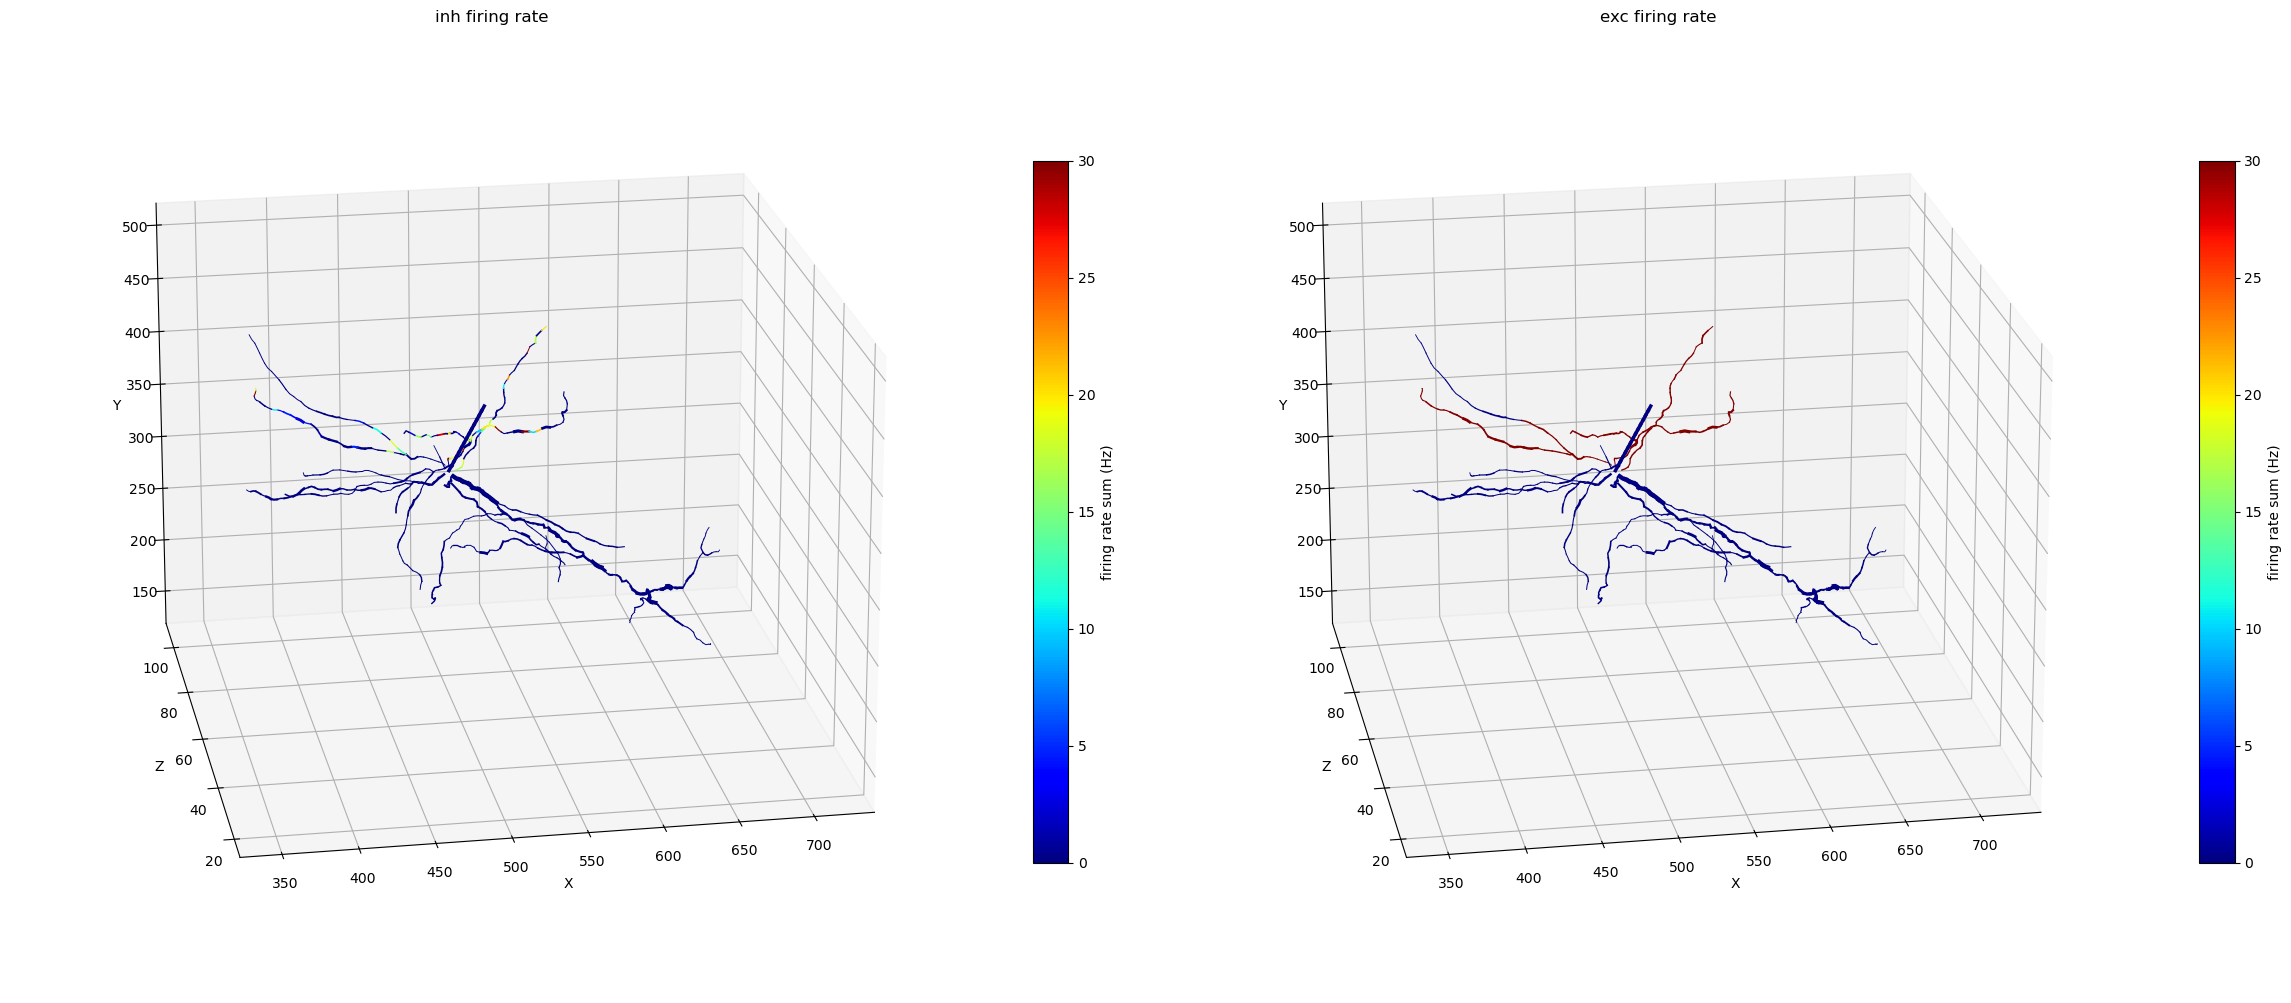

In [15]:
plot_var_on_morph_for_both_syn_types(df_inh=df_inh_grouped,
                                         df_exc=df_exc_grouped,
                                         var='fr_sum',
                                         cbar_label='firing rate sum (Hz)',
                                         title_suffix='firing rate',
                                         save_folder=save_folder,
                                         clim_max = 30)

synapse density

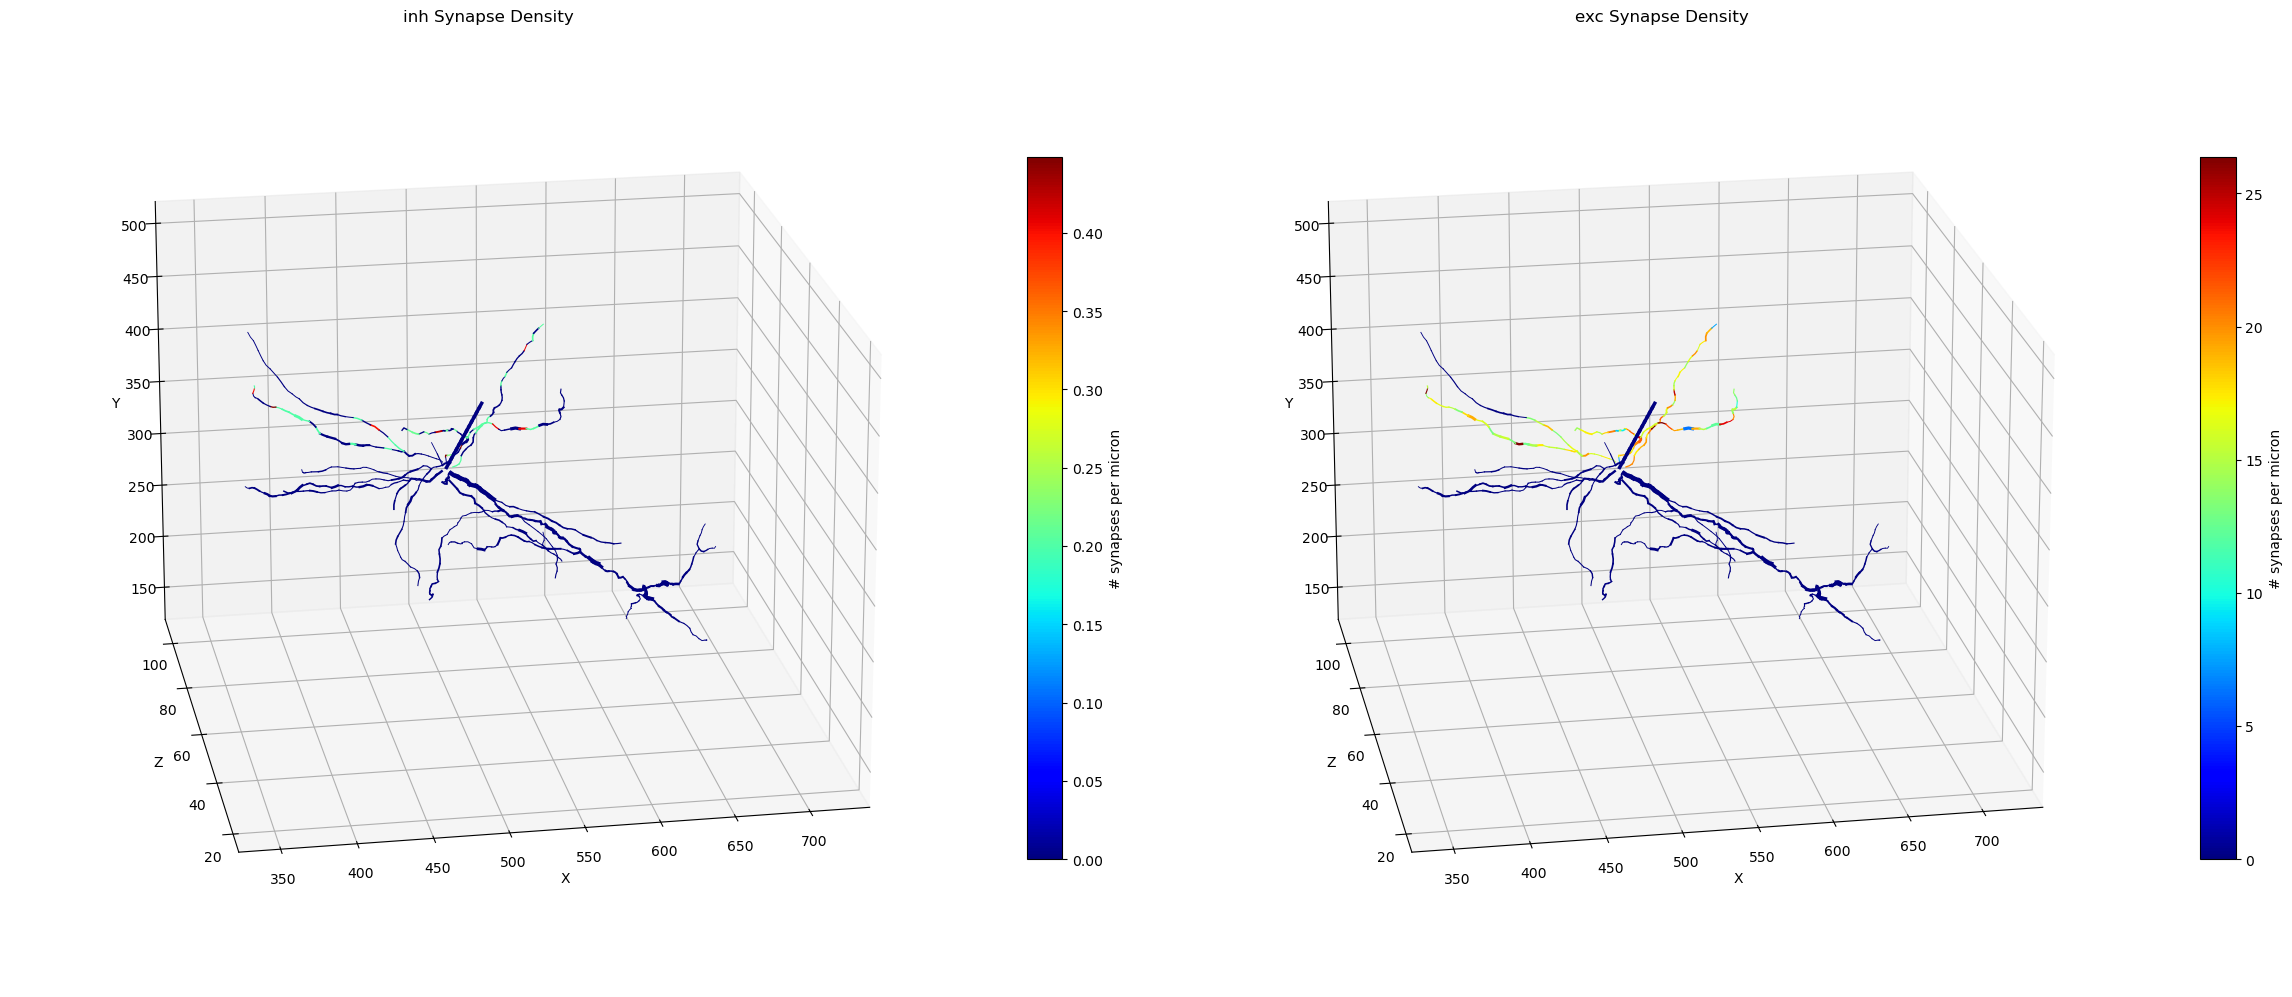

In [16]:
plot_var_on_morph_for_both_syn_types(df_inh=df_inh_grouped,
                                         df_exc=df_exc_grouped,
                                         var='syn_density',
                                         cbar_label='# synapses per micron',
                                         title_suffix='Synapse Density',
                                         save_folder=save_folder,
                                         clim_max=None)

number of synapses

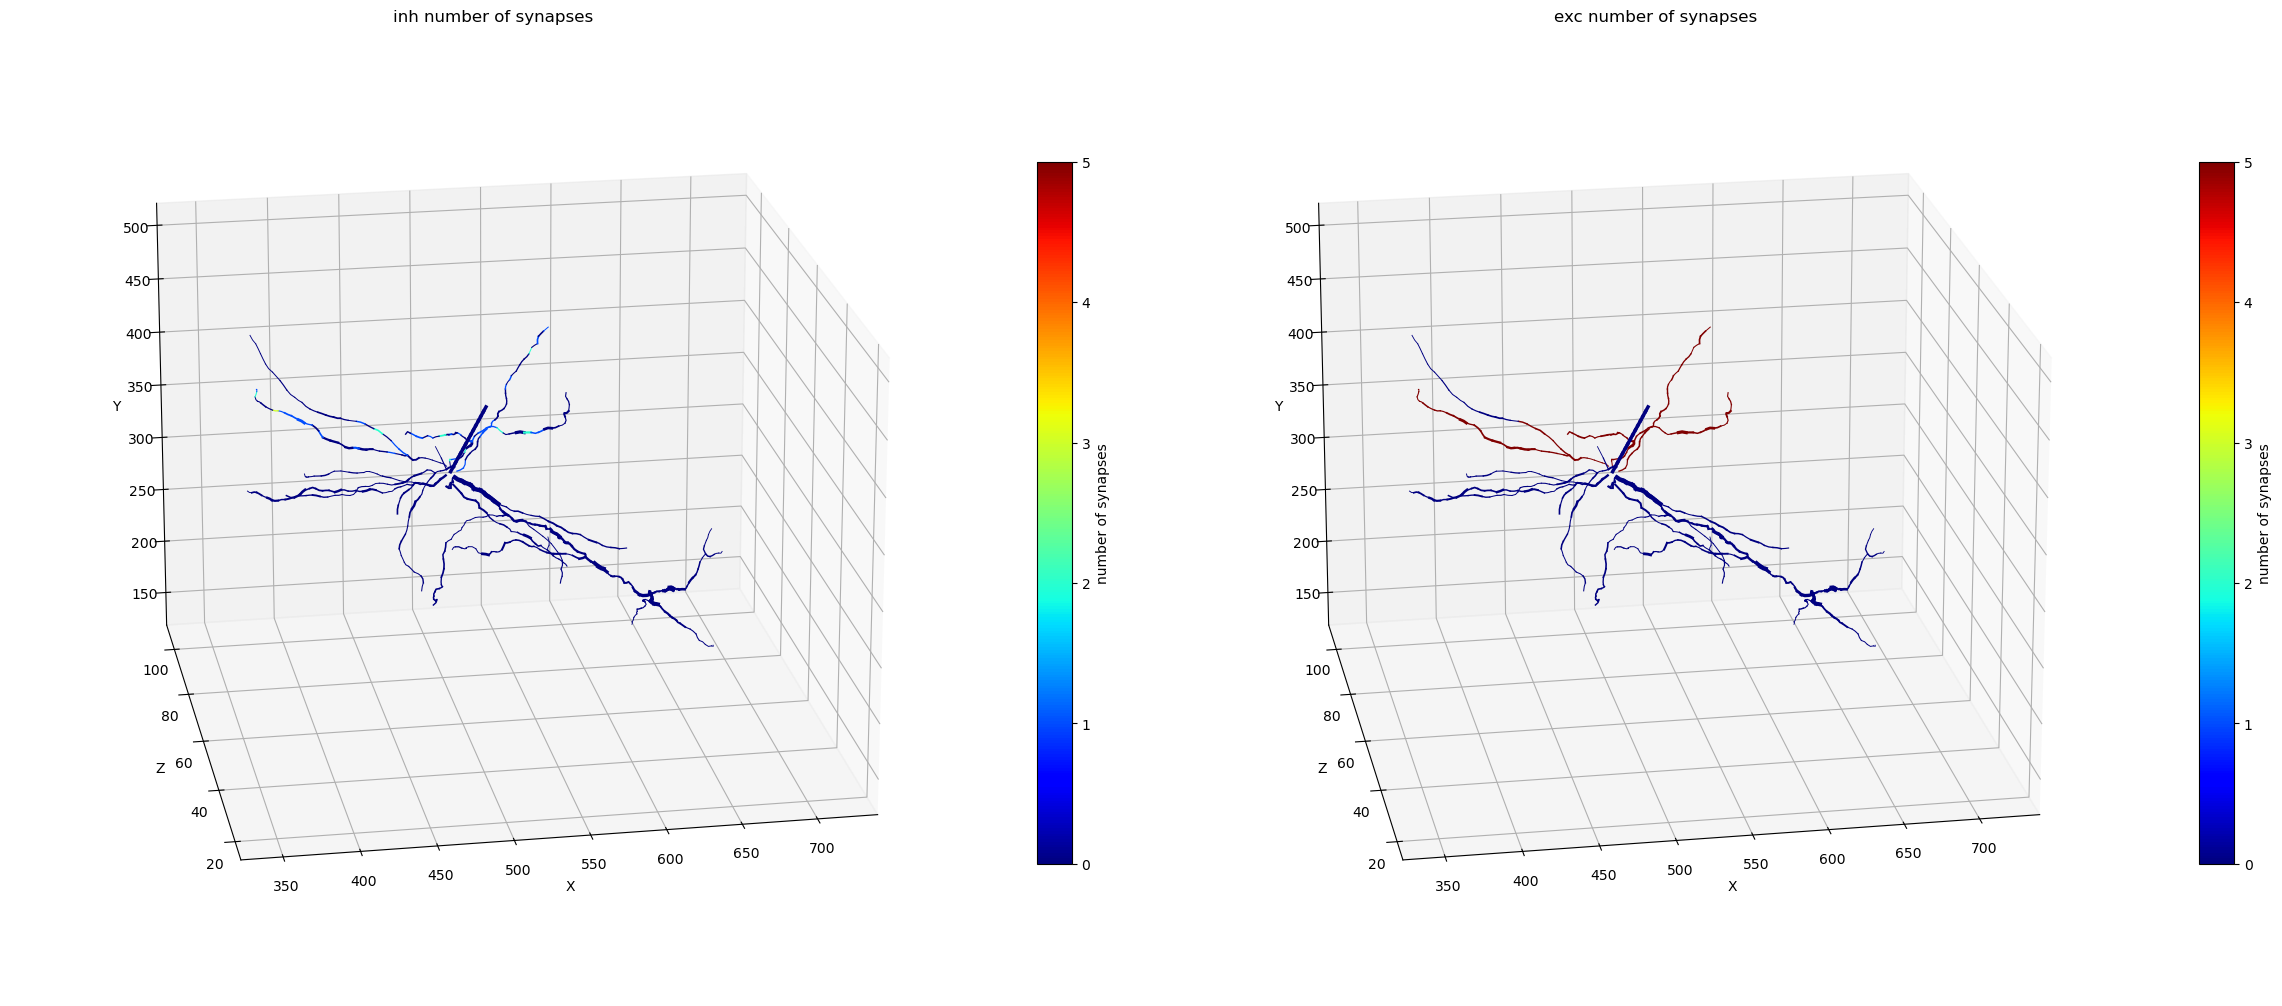

In [17]:
plot_var_on_morph_for_both_syn_types(df_inh=df_inh_grouped,
                                         df_exc=df_exc_grouped,
                                         var='num_syns',
                                         cbar_label='number of synapses',
                                         title_suffix='number of synapses',
                                         save_folder=save_folder,
                                         clim_max=5)

In [18]:
np.shape(seg_data)

(464, 24)

In [19]:
np.shape(df_exc_grouped)

(112, 21)